In [1]:
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures"],
    highs=[15000, 4000],
    lows=[1000, 500],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

In [2]:
normalized = ds.run_normalization(feat_key="hvgs")
pca = ds.run_pca(normalized, dims=15)
initialization = ds.build_embedding_initialization(
    pca,
    n_centroids=100,
)
ann_index = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
graph

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='c9f6b2b21b16...')

In [3]:
loaded_graph = ds.load_graph()
loaded_graph.shape, loaded_graph.nnz

((4360, 4360), 47960)

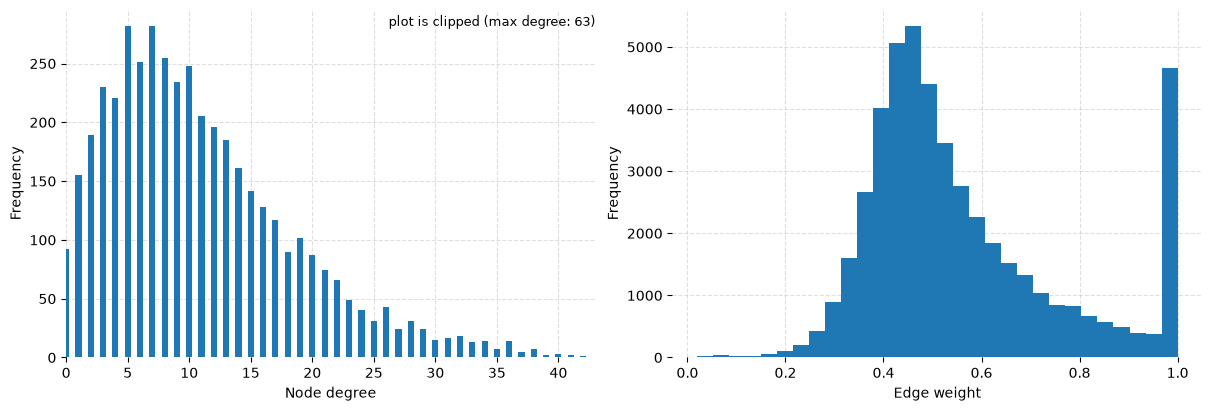

In [4]:
splt.graph_qc(loaded_graph)

In [5]:
state = ds.get_assay_state("RNA")
{
    "cell selection": state.cell_key,
    "feature selection": state.feat_key,
    "normalization": state.normalized,
    "reduction": state.reduction,
    "neighbours": state.neighbors,
    "connectivity": state.connectivity_map,
}

{'cell selection': 'I',
 'feature selection': 'hvgs',
 'normalization': ArtifactRef(assay='RNA', kind='normalized', artifact_id='552ebcd22e98...'),
 'reduction': ArtifactRef(assay='RNA', kind='reduction', artifact_id='0275d4549c61...'),
 'neighbours': ArtifactRef(assay='RNA', kind='neighbors', artifact_id='79fedf0d992e...'),
 'connectivity': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='c9f6b2b21b16...')}

Training UMAP: 100 / 100 complete

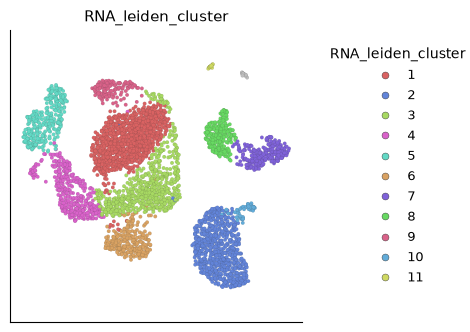

In [6]:
umap = ds.run_umap(
    n_epochs=100,
    parallel=True,
)
clusters = ds.run_leiden_clustering(resolution=0.5)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
)

In [7]:
ds.inspect_artifact(clusters).parameters

{'resolution': 0.5,
 'symmetric_graph': False,
 'graph_upper_only': False,
 'random_seed': 4444}

In [8]:
neighbors_k21 = ds.query_neighbors(
    ann_index,
    k=21,
    update_state=False,
)
graph_k21 = ds.build_connectivity_map(
    neighbors_k21,
    update_state=False,
)

current_state = ds.get_assay_state("RNA")
current_state.connectivity_map == graph, graph_k21 != graph

Identifying neighbors: 1 / 1 complete

(True, True)

In [9]:
ds.run_leiden_clustering(
    graph_k21,
    resolution=0.5,
    label="leiden_k21",
)
pd.crosstab(
    pd.Series(ds.cells.fetch("RNA_leiden_cluster"), name="k=11"),
    pd.Series(ds.cells.fetch("RNA_leiden_k21"), name="k=21"),
)

k=21,1,2,3,4,5,6,7,8,9
k=11,,,,,,,,,
1,1206,0,0,0,0,17,0,0,0
2,0,699,0,32,0,0,0,0,0
3,63,0,163,444,0,1,0,0,1
4,0,0,362,0,35,0,0,0,0
5,0,0,0,0,307,0,0,0,0
6,0,0,3,5,0,266,0,0,0
7,0,0,0,0,0,0,263,7,0
8,0,0,0,0,0,0,0,258,0
9,1,0,0,0,0,0,0,0,144
